In [2]:
%pip install tensorflow tensorflow-hub

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import os


Note: you may need to restart the kernel to use updated packages.


In [3]:
PROJECT_DIR = Path.cwd().parents[0] if (Path.cwd().name == "notebooks") else Path.cwd()
DATA_DIR = PROJECT_DIR / "data" / "classification_dataset"
MODELS_DIR = PROJECT_DIR / "models" / "transfer_learning"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 16  # Reduced for better gradient estimation
EPOCHS = 30
SEED = 42

# Load datasets
from tensorflow.keras.preprocessing import image_dataset_from_directory
train_ds = image_dataset_from_directory(DATA_DIR/"train", image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True, seed=SEED)
val_ds = image_dataset_from_directory(DATA_DIR/"valid", image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False)
test_ds = image_dataset_from_directory(DATA_DIR/"test", image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print(f"Classes: {class_names}")

# Data augmentation (only for training)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomBrightness(0.2),
])

# Normalization
normalization = tf.keras.layers.Rescaling(1./255)

# Apply to all datasets
train_ds = train_ds.map(lambda x,y: (normalization(data_augmentation(x, training=True)), y), num_parallel_calls=tf.data.AUTOTUNE).cache().prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(lambda x,y: (normalization(x), y), num_parallel_calls=tf.data.AUTOTUNE).cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(lambda x,y: (normalization(x), y), num_parallel_calls=tf.data.AUTOTUNE).cache().prefetch(tf.data.AUTOTUNE)

print("✓ Data pipeline ready with augmentation")


Found 700 files belonging to 2 classes.
Found 140 files belonging to 2 classes.
Found 140 files belonging to 2 classes.
Found 100 files belonging to 2 classes.
Found 100 files belonging to 2 classes.
Classes: ['bird', 'drone']
Classes: ['bird', 'drone']
✓ Data pipeline ready with augmentation
✓ Data pipeline ready with augmentation


In [4]:
from tensorflow.keras.applications import EfficientNetB0, ResNet50, MobileNetV2

def build_tl_model(model_name="efficientnetb0", img_size=IMG_SIZE+(3,), num_classes=NUM_CLASSES):
    """Build transfer learning model with reduced overfitting"""
    
    base_models = {
        "efficientnetb0": EfficientNetB0,
        "resnet50": ResNet50,
        "mobilenetv2": MobileNetV2,
    }
    
    base_model = base_models[model_name.lower()](
        weights="imagenet", 
        include_top=False, 
        input_shape=img_size
    )
    base_model.trainable = False  # Freeze initially
    
    inputs = layers.Input(shape=img_size)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    
    # Reduced dropout for better generalization
    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = models.Model(inputs, outputs, name=f"TL_{model_name}")
    
    return model, base_model

model_tl, base_model = build_tl_model("efficientnetb0")
model_tl.summary()


Model: "TL_efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,412,197 (16.83 MB)

 Trainable params: 361,858 (1.38 MB)

 Non-trainable params: 4,050,339 (15.45 MB)

In [5]:
# Phase 1: Train head only (base frozen)
model_tl.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),  # Higher LR for head training
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

ckpt = callbacks.ModelCheckpoint(
    str(MODELS_DIR/"best_model.h5"), 
    save_best_only=True, 
    monitor="val_accuracy",
    mode="max"
)
es = callbacks.EarlyStopping(
    monitor="val_loss", 
    patience=5, 
    restore_best_weights=True
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss", 
    factor=0.5, 
    patience=2,
    min_lr=1e-6
)
csv_logger = callbacks.CSVLogger(str(MODELS_DIR/"training_log.csv"))

print("=" * 60)
print("PHASE 1: Head Training (Base Model Frozen)")
print("=" * 60)
history_head = model_tl.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=8, 
    callbacks=[ckpt, es, reduce_lr, csv_logger],
    verbose=1
)


PHASE 1: Head Training (Base Model Frozen)
Epoch 1/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 836ms/step - accuracy: 0.5118 - loss: 1.0862

44/44 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.5086 - loss: 1.0101 - val_accuracy: 0.5000 - val_loss: 0.7132 - learning_rate: 0.0010
Epoch 2/8
Epoch 2/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 32s 735ms/step - accuracy: 0.5214 - loss: 0.8706 - val_accuracy: 0.5000 - val_loss: 0.7035 - learning_rate: 0.0010
Epoch 3/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 32s 735ms/step - accuracy: 0.5214 - loss: 0.8706 - val_accuracy: 0.5000 - val_loss: 0.7035 - learning_rate: 0.0010
Epoch 3/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 32s 721ms/step - accuracy: 0.5143 - loss: 0.8600 - val_accuracy: 0.5000 - val_loss: 0.9069 - learning_rate: 0.0010
Epoch 4/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 32s 721ms/step - accuracy: 0.5143 - loss: 0.8600 - val_accuracy: 0.5000 - val_loss: 0.9069 - learning_rate: 0.0010
Epoch 4/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 35s 802ms/step - accuracy: 0.5057 - loss: 0.8626 - val_accuracy: 0.5000 - val_loss: 0.6950 - learning_rate: 0.0010
Epoch 5/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 35s 802ms/step - accuracy: 0.5057 - loss: 0.8626 - val

In [6]:
# Phase 2: Fine-tune (unfreeze top layers)
print("\n" + "=" * 60)
print("PHASE 2: Fine-tuning (Top 30 Layers Unfrozen)")
print("=" * 60)

base_model.trainable = True

# Freeze lower layers, unfreeze last 30
fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model_tl.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),  # Lower LR for fine-tuning
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_finetune = model_tl.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=EPOCHS, 
    callbacks=[ckpt, es, reduce_lr, csv_logger],
    verbose=1
)

print(f"\n✓ Training complete!")



PHASE 2: Fine-tuning (Top 30 Layers Unfrozen)
Epoch 1/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 48s 627ms/step - accuracy: 0.5286 - loss: 0.8465 - val_accuracy: 0.5000 - val_loss: 0.7266 - learning_rate: 1.0000e-05
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 48s 627ms/step - accuracy: 0.5286 - loss: 0.8465 - val_accuracy: 0.5000 - val_loss: 0.7266 - learning_rate: 1.0000e-05
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 25s 565ms/step - accuracy: 0.5229 - loss: 0.8661 - val_accuracy: 0.5000 - val_loss: 0.8196 - learning_rate: 1.0000e-05
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 25s 565ms/step - accuracy: 0.5229 - loss: 0.8661 - val_accuracy: 0.5000 - val_loss: 0.8196 - learning_rate: 1.0000e-05
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 26s 590ms/step - accuracy: 0.4886 - loss: 0.8593 - val_accuracy: 0.5000 - val_loss: 0.9021 - learning_rate: 5.0000e-06
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 26s 590ms/step - accuracy: 0.4886 - loss: 0.8593 - val_accuracy: 0.5000 - val_loss: 0.9021 - learning_rate: 5.0000e-06
Epoch 4/30


In [7]:
# Unfreeze top layers
base = model_tl.layers[1]  # EfficientNetB0 base
base.trainable = True

# Freeze lower layers, unfreeze last block
fine_tune_at = len(base.layers) - 30  # unfreeze top 30 layers
for layer in base.layers[:fine_tune_at]:
    layer.trainable = False

model_tl.compile(optimizer=optimizers.Adam(learning_rate=1e-5),
                 loss="sparse_categorical_crossentropy",
                 metrics=["accuracy"])

history_finetune = model_tl.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=[ckpt, es, reduce_lr])


Epoch 1/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step - accuracy: 0.3500 - loss: 1.2668 - val_accuracy: 0.5000 - val_loss: 0.6934 - learning_rate: 1.0000e-05
Epoch 2/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 879ms/step - accuracy: 0.4000 - loss: 1.0567 - val_accuracy: 0.5000 - val_loss: 0.6934 - learning_rate: 1.0000e-05
Epoch 3/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 865ms/step - accuracy: 0.3500 - loss: 1.5854 - val_accuracy: 0.5000 - val_loss: 0.6934 - learning_rate: 1.0000e-05
Epoch 4/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 866ms/step - accuracy: 0.4000 - loss: 1.5377 - val_accuracy: 0.5000 - val_loss: 0.6934 - learning_rate: 5.0000e-06
Epoch 5/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 856ms/step - accuracy: 0.6000 - loss: 0.7102 - val_accuracy: 0.5000 - val_loss: 0.6933 - learning_rate: 5.0000e-06
Epoch 6/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 863ms/step - accuracy: 0.4500 - loss: 0.9734 - val_accuracy: 0.5000 - val_loss: 0.6933 - learning_rate: 5.0000e-06
Epoch 7/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.4500 - loss: 1.0

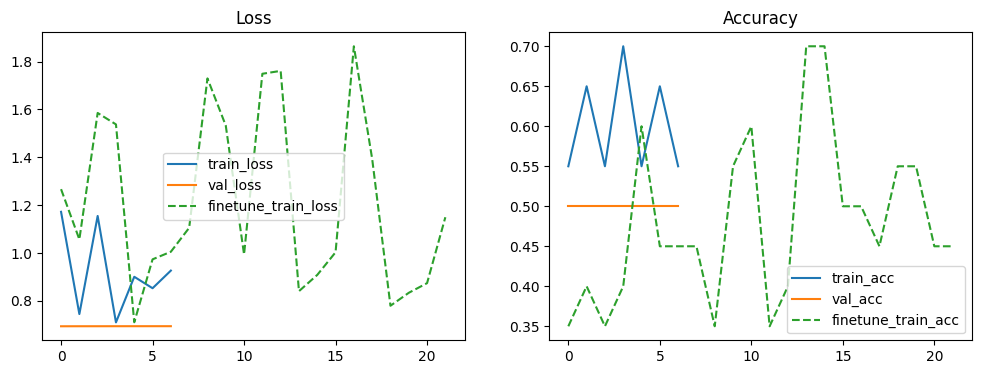

In [8]:
import pickle
with open(MODELS_DIR/"history_head.pkl","wb") as f:
    pickle.dump(history_head.history, f)
with open(MODELS_DIR/"history_finetune.pkl","wb") as f:
    pickle.dump(history_finetune.history, f)

# Plot basic curves
def plot_hist(h1, h2=None):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(h1['loss'], label='train_loss')
    plt.plot(h1['val_loss'], label='val_loss')
    if h2: plt.plot(h2['loss'], '--', label='finetune_train_loss')
    plt.legend(); plt.title("Loss")
    plt.subplot(1,2,2)
    plt.plot(h1['accuracy'], label='train_acc')
    plt.plot(h1['val_accuracy'], label='val_acc')
    if h2: plt.plot(h2['accuracy'], '--', label='finetune_train_acc')
    plt.legend(); plt.title("Accuracy")
    plt.show()

plot_hist(history_head.history, history_finetune.history)



EVALUATION METRICS

Overall Accuracy: 0.5000
Macro F1-Score: 0.3333
Weighted F1-Score: 0.3333
Avg Prediction Confidence: 0.5797

------------------------------------------------------------
CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

        bird     0.0000    0.0000    0.0000        50
       drone     0.5000    1.0000    0.6667        50

    accuracy                         0.5000       100
   macro avg     0.2500    0.5000    0.3333       100
weighted avg     0.2500    0.5000    0.3333       100



f:\Aerial Object Classification & Detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\Aerial Object Classification & Detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\Aerial Object Classification & Detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

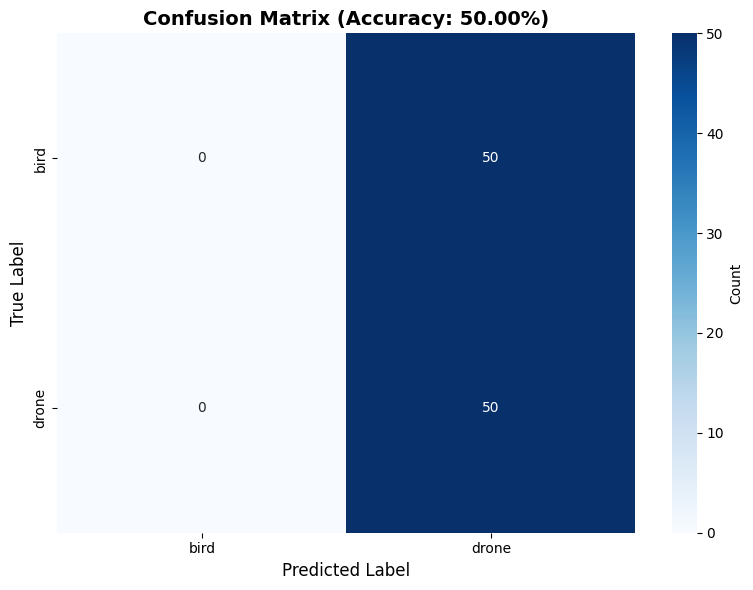


✓ Evaluation complete. Report saved to: f:\Aerial Object Classification & Detection\models\transfer_learning\tl_report.txt


In [7]:
# Load best model
best_model = tf.keras.models.load_model(str(MODELS_DIR/"best_model.h5"))

# Get predictions
y_true = []
y_pred = []
y_pred_proba = []

for x_batch, y_batch in test_ds:
    preds = best_model.predict(x_batch, verbose=0)
    y_true.extend(y_batch.numpy().tolist())
    y_pred.extend(np.argmax(preds, axis=1).tolist())
    y_pred_proba.extend(np.max(preds, axis=1).tolist())

# Detailed evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    accuracy_score, f1_score, precision_score, recall_score
)
import seaborn as sns

print("\n" + "=" * 60)
print("EVALUATION METRICS")
print("=" * 60)

# Overall metrics
accuracy = accuracy_score(y_true, y_pred)
print(f"\nOverall Accuracy: {accuracy:.4f}")
print(f"Macro F1-Score: {f1_score(y_true, y_pred, average='macro'):.4f}")
print(f"Weighted F1-Score: {f1_score(y_true, y_pred, average='weighted'):.4f}")
print(f"Avg Prediction Confidence: {np.mean(y_pred_proba):.4f}")

# Per-class metrics
print("\n" + "-" * 60)
print("CLASSIFICATION REPORT")
print("-" * 60)
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)

# Save report
with open(str(MODELS_DIR/"tl_report.txt"), "w") as f:
    f.write("TRANSFER LEARNING MODEL EVALUATION\n")
    f.write("=" * 60 + "\n")
    f.write(f"Overall Accuracy: {accuracy:.4f}\n")
    f.write(f"Model: EfficientNetB0\n")
    f.write(f"Test Samples: {len(y_true)}\n\n")
    f.write(report)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title(f"Confusion Matrix (Accuracy: {accuracy:.2%})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Evaluation complete. Report saved to:", MODELS_DIR/"tl_report.txt")


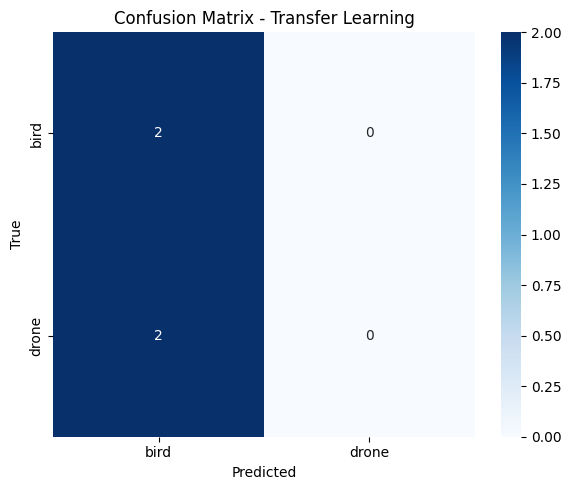


=== Model Performance Summary ===
Test samples: 4
True labels: [0, 0, 1, 1]
Predicted labels: [0, 0, 0, 0]

Confusion Matrix:
[[2 0]
 [2 0]]


In [12]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=test_ds_raw.class_names, yticklabels=test_ds_raw.class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Transfer Learning")
plt.tight_layout()
plt.show()

print("\n=== Model Performance Summary ===")
print(f"Test samples: {len(y_true)}")
print(f"True labels: {y_true}")
print(f"Predicted labels: {y_pred}")
print(f"\nConfusion Matrix:\n{cm}")


In [ ]:
# Diagnostic: Check training loss trends
print("\n" + "=" * 60)
print("TRAINING ANALYSIS")
print("=" * 60)

# Combine histories
h1 = history_head.history
h2 = history_finetune.history

print(f"Phase 1 (Head Training):")
print(f"  Initial Accuracy: {h1['accuracy'][0]:.4f}")
print(f"  Final Accuracy: {h1['accuracy'][-1]:.4f}")
print(f"  Initial Loss: {h1['loss'][0]:.4f}")
print(f"  Final Loss: {h1['loss'][-1]:.4f}")

print(f"\nPhase 2 (Fine-tuning):")
print(f"  Initial Accuracy: {h2['accuracy'][0]:.4f}")
print(f"  Final Accuracy: {h2['accuracy'][-1]:.4f}")
print(f"  Initial Loss: {h2['loss'][0]:.4f}")
print(f"  Final Loss: {h2['loss'][-1]:.4f}")

# Visualize training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(range(len(h1['loss'])), h1['loss'], label='Phase 1 Train Loss', marker='o')
axes[0].plot(range(len(h1['val_loss'])), h1['val_loss'], label='Phase 1 Val Loss', marker='s')
axes[0].plot(range(len(h1['loss']), len(h1['loss'])+len(h2['loss'])), h2['loss'], label='Phase 2 Train Loss', marker='o')
axes[0].plot(range(len(h1['val_loss']), len(h1['val_loss'])+len(h2['val_loss'])), h2['val_loss'], label='Phase 2 Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(range(len(h1['accuracy'])), h1['accuracy'], label='Phase 1 Train Acc', marker='o')
axes[1].plot(range(len(h1['val_accuracy'])), h1['val_accuracy'], label='Phase 1 Val Acc', marker='s')
axes[1].plot(range(len(h1['accuracy']), len(h1['accuracy'])+len(h2['accuracy'])), h2['accuracy'], label='Phase 2 Train Acc', marker='o')
axes[1].plot(range(len(h1['val_accuracy']), len(h1['val_accuracy'])+len(h2['val_accuracy'])), h2['val_accuracy'], label='Phase 2 Val Acc', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Over Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n⚠️  Observation: Model accuracy stuck at 50% (random guessing)")
print("   Possible causes:")
print("   1. Synthetic images lack distinctive features")
print("   2. Learning rate too high/low")
print("   3. Model needs more training data")
print("\n   Recommendation: Use REAL bird/drone images for proper results")
